# CIDIoT : Privacy-Preserving Collaborative Intrusion Detection in Edge IoT

## 1. Imports and environment

In [1]:
import os
import copy
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,
)

try:
    from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE
    HAVE_IMBLEARN = True
except Exception:
    HAVE_IMBLEARN = False
    print("[warn] imbalanced-learn not installed - oversampling will be skipped.")

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch {torch.__version__}")

Using device: cuda
PyTorch 2.5.1+cu121


## 2. Configuration

In [2]:
RUN_SEEDS = [43, 44, 45]

NUM_CLIENTS  = 5
NUM_ROUNDS   = 30
BATCH_SIZE   = 32
IID          = False
NUM_SHARDS   = 100
MIN_SHARDS   = 1
MAX_SHARDS   = 30

LATENT_DIM   = 100
ADAM_LR      = 0.001
ADAM_B1      = 0.5
ADAM_B2      = 0.999
ND_LOCAL     = 5
LAMBDA_ADV   = 0.0002
GP_WEIGHT    = 10.0
PHI          = 10.0
TAU          = NUM_CLIENTS - 1

DP_ENABLED   = True
DP_CLIP_C    = 1.0
DP_SIGMA     = 1.0

WEISZFELD_ITERS = 8
WEISZFELD_EPS   = 1e-8

DATA_PATH = "../../data/CICIoT2023_extracted.csv"

print("Configuration loaded.")
print(f"  seeds        = {RUN_SEEDS}")
print(f"  clients (K)  = {NUM_CLIENTS}")
print(f"  rounds  (T)  = {NUM_ROUNDS}")
print(f"  DP           = {'on' if DP_ENABLED else 'off'} (sigma={DP_SIGMA}, C={DP_CLIP_C})")

Configuration loaded.
  seeds        = [43, 44, 45]
  clients (K)  = 5
  rounds  (T)  = 30
  DP           = on (sigma=1.0, C=1.0)


In [3]:
def set_seed(seed: int):
    """Seed every source of randomness so a run is reproducible."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
NORMAL_CLASS_NAME = "Benign"

def detection_metrics(y_true, y_pred, class_names, normal_name=NORMAL_CLASS_NAME):
    """Binary attack-vs-normal DR and FAR from multiclass predictions.

    positive = attack (any non-normal class); negative = normal (benign).
      DR  = TP / (TP + FN)   detection rate  (attack recall)
      FAR = FP / (FP + TN)   false alarm rate (false positive rate)
    Returns (dr, far); either is nan if its denominator is zero.
    """
    names = [str(c) for c in class_names]
    if normal_name in names:
        normal_id = names.index(normal_name)
    else:

        normal_id = -1

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_attack = y_true != normal_id
    pred_attack = y_pred != normal_id

    TP = int(np.sum(true_attack & pred_attack))
    FN = int(np.sum(true_attack & ~pred_attack))
    FP = int(np.sum(~true_attack & pred_attack))
    TN = int(np.sum(~true_attack & ~pred_attack))

    dr  = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
    far = FP / (FP + TN) if (FP + TN) > 0 else float("nan")
    return dr, far

## 3. Data pipeline

In [5]:
def load_ciciot_extracted_dataset(file_path=DATA_PATH, seed=42):
    """Load and preprocess the CIC-IoT2023 extracted dataset.

    Returns train/test tensors, the class names, and the number of classes.
    The pipeline (split, scaling, oversampling) is fully controlled by `seed`.
    """
    print("Loading CIC-IoT2023 extracted dataset...")
    df = pd.read_csv(file_path)

    target_column = "category"
    df["label"] = df[target_column]

    y_init = df["label"].copy()
    drop_cols = ["label"]
    if "category" in df.columns:
        drop_cols.append("category")
    if "Label" in df.columns:
        drop_cols.append("Label")
    X_init = df.drop(columns=drop_cols).copy()

    non_numeric_cols = X_init.select_dtypes(exclude=[np.number]).columns.tolist()
    for col in non_numeric_cols:
        le = LabelEncoder()
        X_init[col] = le.fit_transform(X_init[col].astype(str))

    X_init = X_init.apply(lambda _col: _col.map(lambda v: str(v).strip() if isinstance(v, str) else v))
    X_init = X_init.apply(pd.to_numeric, errors="coerce")
    X_init = X_init.replace([np.inf, -np.inf], np.nan).fillna(0)

    y_init = y_init.astype(str).str.strip().replace(["nan", "None", ""], np.nan)
    df_clean = pd.concat([X_init, y_init.rename("label")], axis=1).dropna(subset=["label"])
    X_init = df_clean.drop(columns=["label"])
    y_init = df_clean["label"]

    X_init_array = X_init.values.astype(np.float64)
    y_init_array = y_init.values

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_init_array)

    X_train, X_test, y_train, y_test = train_test_split(
        X_init_array, y_encoded, test_size=0.3, random_state=seed, stratify=y_encoded
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    class_to_id = {name: i for i, name in enumerate(label_encoder.classes_)}
    y_train_counts = pd.Series(y_train).value_counts().sort_index()

    if HAVE_IMBLEARN:
        safe_min = 1400
        ros_targets = {}
        for cname in ["Web", "BruteForce"]:
            if cname in class_to_id:
                cid = class_to_id[cname]
                current = int(y_train_counts.get(cid, 0))
                if 0 < current < safe_min:
                    ros_targets[cid] = safe_min
        if ros_targets:
            ros = RandomOverSampler(sampling_strategy=ros_targets, random_state=seed)
            X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)
        else:
            X_train_ros, y_train_ros = X_train_scaled, y_train

        y_ros_counts = pd.Series(y_train_ros).value_counts().sort_index()
        target = int(0.40 * max(y_ros_counts))
        smote_strategy = {cid: target for cid, cnt in y_ros_counts.items() if cnt < target}
        if smote_strategy:
            bsmote = BorderlineSMOTE(sampling_strategy=smote_strategy, random_state=seed, k_neighbors=3)
            X_train_bal, y_train_bal = bsmote.fit_resample(X_train_ros, y_train_ros)
        else:
            X_train_bal, y_train_bal = X_train_ros, y_train_ros
    else:
        X_train_bal, y_train_bal = X_train_scaled, y_train

    X_train_tensor = torch.FloatTensor(X_train_bal)
    y_train_tensor = torch.LongTensor(y_train_bal)
    X_test_tensor  = torch.FloatTensor(X_test_scaled)
    y_test_tensor  = torch.LongTensor(y_test)

    class_names = label_encoder.classes_
    num_classes = len(class_names)

    print(f"  classes  : {list(class_names)}")
    print(f"  #features={X_train_tensor.shape[1]}  #train={len(X_train_tensor)}  #test={len(X_test_tensor)}")
    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, class_names, num_classes

## 4. Non-IID partitioning

In [6]:
def partition_dataset_iid(dataset, num_partitions, num_classes):
    """Balanced IID partition: each partition receives a proportional slice of every class."""
    num_samples = len(dataset)
    labels = np.array([int(dataset[i][1]) for i in range(num_samples)])
    indices_by_class = [[] for _ in range(num_classes)]
    for idx, label in enumerate(labels):
        indices_by_class[label].append(idx)
    partitions = [[] for _ in range(num_partitions)]
    for c in range(num_classes):
        indices = indices_by_class[c]
        np.random.shuffle(indices)
        per = len(indices) // num_partitions
        rem = len(indices) % num_partitions
        start = 0
        for p in range(num_partitions):
            extra = 1 if p < rem else 0
            end = start + per + extra
            partitions[p].extend(indices[start:end])
            start = end
    for p in range(num_partitions):
        np.random.shuffle(partitions[p])
    return partitions

def partition_dataset_shards_noniid(dataset, num_clients, num_shards=100,
                                    min_shards=1, max_shards=30, seed=42, verbose=True):
    """Shard-based Non-IID partition (label-sorted shards distributed unevenly across clients)."""
    rng = np.random.default_rng(seed)
    n = len(dataset)
    labels = np.array([int(dataset[i][1]) for i in range(n)])
    sorted_indices = np.argsort(labels)

    shard_sizes = np.full(num_shards, n // num_shards, dtype=int)
    shard_sizes[: (n % num_shards)] += 1
    shards, start = [], 0
    for sz in shard_sizes:
        shards.append(sorted_indices[start:start + sz].tolist())
        start += sz

    shards_per_client = np.full(num_clients, min_shards, dtype=int)
    remaining = num_shards - shards_per_client.sum()
    while remaining > 0:
        c = rng.integers(0, num_clients)
        if shards_per_client[c] < max_shards:
            shards_per_client[c] += 1
            remaining -= 1

    shard_ids = rng.permutation(num_shards).tolist()
    partitions = [[] for _ in range(num_clients)]
    ptr = 0
    for c in range(num_clients):
        take = int(shards_per_client[c])
        for sid in shard_ids[ptr:ptr + take]:
            partitions[c].extend(shards[sid])
        ptr += take
    for c in range(num_clients):
        rng.shuffle(partitions[c])

    if verbose:
        print(f"Non-IID (shards): num_shards={num_shards}, shards/client in [{min_shards},{max_shards}]")
        for c in range(num_clients):
            part_labels = labels[partitions[c]]
            uniq, cnt = np.unique(part_labels, return_counts=True)
            dist = {int(u): int(k) for u, k in zip(uniq, cnt)}
            print(f"  Client {c}: {len(partitions[c])} samples | #classes={len(dist)} | dist={dist}")
    return partitions

## 5. Model: TCN building blocks

In [7]:
class Chomp1d(nn.Module):
    """Removes trailing padding so the convolution stays strictly causal."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else x

class TCNResidualBlock(nn.Module):
    """Two dilated causal conv layers + GroupNorm + residual connection."""
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.1, activation="lrelu"):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.chomp1 = Chomp1d(pad)
        self.gn1 = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.chomp2 = Chomp1d(pad)
        self.gn2 = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)

        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.act = (lambda z: F.leaky_relu(z, 0.2)) if activation == "lrelu" else F.relu

    def forward(self, x):
        out = self.act(self.gn1(self.chomp1(self.conv1(x))))
        out = self.drop(out)
        out = self.act(self.gn2(self.chomp2(self.conv2(out))))
        out = self.drop(out)
        res = x if self.downsample is None else self.downsample(x)
        return self.act(out + res)

### 5.1 Generator and discriminator

In [8]:
class TCNGenerator(nn.Module):
    """Conditional TCN generator G on the cloud (single G in the 1-vs-K structure)."""
    def __init__(self, latent_dim, num_features, num_classes, hidden=64, seq_len=16):
        super().__init__()
        self.seq_len = seq_len
        self.num_features = num_features
        self.label_emb = nn.Embedding(num_classes, latent_dim)
        self.fc_in = nn.Linear(latent_dim * 2, hidden * seq_len)
        self.tcn = TCNResidualBlock(hidden, hidden, kernel_size=3, dilation=1, activation="lrelu")
        self.fc_out = nn.Linear(hidden * seq_len, num_features)

    def forward(self, z, y):
        c = self.label_emb(y)
        h = torch.cat([z, c], dim=1)
        h = self.fc_in(h)
        h = h.view(h.size(0), -1, self.seq_len)
        h = self.tcn(h)
        h = h.flatten(1)
        return self.fc_out(h)

class TCNDiscriminator(nn.Module):
    """CLS-GAN discriminator on each edge node: source head (real/fake) + class head (multiclass IDS)."""
    def __init__(self, num_features, num_classes, hidden=64, seq_len=16):
        super().__init__()
        self.seq_len = seq_len
        self.fc_in = nn.Linear(num_features, hidden * seq_len)
        self.tcn1 = TCNResidualBlock(hidden, hidden, kernel_size=3, dilation=1, activation="lrelu")
        self.tcn2 = TCNResidualBlock(hidden, hidden, kernel_size=3, dilation=2, activation="lrelu")
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.source_head = nn.Linear(hidden, 1)
        self.class_head  = nn.Linear(hidden, num_classes)

    def features(self, x):
        h = self.fc_in(x).view(x.size(0), -1, self.seq_len)
        h = self.tcn1(h)
        h = self.tcn2(h)
        h = self.pool(h).squeeze(-1)
        return h

    def forward(self, x):
        h = self.features(x)
        return self.source_head(h), self.class_head(h)

## 6. Edge node

In [9]:
class EdgeNode:
    """One edge server ES_k: private partition + local discriminator D_k + DP gradient upload."""
    def __init__(self, cid, dataset, indices, num_features, num_classes, class_names):
        self.cid = cid
        self.num_features = num_features
        self.num_classes = num_classes
        self.subset = Subset(dataset, indices)
        self.loader = DataLoader(self.subset, batch_size=BATCH_SIZE, shuffle=True)

        self.D = TCNDiscriminator(num_features, num_classes).to(DEVICE)
        self.optD = optim.Adam(self.D.parameters(), lr=ADAM_LR, betas=(ADAM_B1, ADAM_B2))

        labels = np.array([int(dataset[i][1]) for i in indices])
        counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
        self.n_k = int(counts.sum())
        self.p_k = counts / max(counts.sum(), 1)

    def train_discriminator(self, G, nd_iters=ND_LOCAL):
        """CLS-GAN discriminator update on real + generated data."""
        self.D.train()
        G.eval()
        ce = nn.CrossEntropyLoss()
        it = iter(self.loader)
        for _ in range(nd_iters):
            try:
                x_real, y_real = next(it)
            except StopIteration:
                it = iter(self.loader)
                x_real, y_real = next(it)
            x_real = x_real.to(DEVICE)
            y_real = y_real.to(DEVICE)
            b = x_real.size(0)

            with torch.no_grad():
                z = torch.randn(b, LATENT_DIM, device=DEVICE)
                y_fake = torch.randint(0, self.num_classes, (b,), device=DEVICE)
                x_fake = G(z, y_fake)

            self.optD.zero_grad()
            src_real, cls_real = self.D(x_real)
            src_fake, cls_fake = self.D(x_fake)

            margin = (x_real - x_fake).abs().mean(dim=1, keepdim=True)
            adv = torch.clamp(margin + src_real - src_fake, min=0).mean()

            zeta = torch.rand(b, 1, device=DEVICE)
            x_hat = (zeta * x_real + (1 - zeta) * x_fake).requires_grad_(True)
            src_hat, _ = self.D(x_hat)
            grads = torch.autograd.grad(
                outputs=src_hat.sum(), inputs=x_hat,
                create_graph=True, retain_graph=True)[0]
            gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()

            L_adv = LAMBDA_ADV * adv + GP_WEIGHT * gp
            L_cls = ce(cls_real, y_real)

            L_D = L_adv + L_cls
            L_D.backward()
            self.optD.step()

        return float(L_D.detach().cpu())

    def generator_sample_gradient(self, G):
        """DP-noised sample gradient of the generator loss."""
        self.D.eval()
        G.train()
        G.zero_grad()

        z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
        y = torch.randint(0, self.num_classes, (BATCH_SIZE,), device=DEVICE)
        x_fake = G(z, y)
        src_fake, cls_fake = self.D(x_fake)
        ce = nn.CrossEntropyLoss()
        L_G = src_fake.mean() + ce(cls_fake, y)
        L_G.backward()

        grads = []
        for p in G.parameters():
            g = p.grad.detach().clone().flatten() if p.grad is not None\
                else torch.zeros(p.numel(), device=DEVICE)
            grads.append(g)
        flat = torch.cat(grads)

        if DP_ENABLED:
            norm = flat.norm(2) + 1e-12
            flat = flat / torch.clamp(norm / DP_CLIP_C, min=1.0)
            flat = flat + torch.randn_like(flat) * (DP_SIGMA * DP_CLIP_C)

        G.zero_grad()
        return flat.detach()

    def get_discriminator_state(self):
        return copy.deepcopy(self.D.state_dict())

## 7. Cloud controller

In [10]:
class CloudController:
    """Single generator + robust aggregation (KL contribution ratio + geometric median)."""
    def __init__(self, num_features, num_classes):
        self.num_features = num_features
        self.num_classes = num_classes
        self.G = TCNGenerator(LATENT_DIM, num_features, num_classes).to(DEVICE)
        self.optG = optim.Adam(self.G.parameters(), lr=ADAM_LR, betas=(ADAM_B1, ADAM_B2))

    def contribution_ratios(self, edges):
        """KL-divergence contribution ratio w_k, penalizing high-divergence nodes via softmax."""
        N = sum(e.n_k for e in edges)
        Q = np.zeros(self.num_classes)
        for e in edges:
            Q += e.p_k * e.n_k
        Q = Q / max(Q.sum(), 1e-12)

        scores = []
        for e in edges:
            P = e.p_k
            mask = P > 0
            kl = np.sum(P[mask] * np.log((P[mask] + 1e-12) / (Q[mask] + 1e-12)))
            sc_k = (e.n_k / max(N, 1)) * kl
            scores.append(sc_k)
        scores = np.array(scores)

        w = np.exp(-PHI * scores)
        w = w / max(w.sum(), 1e-12)
        return w

    @staticmethod
    def geometric_median(grads, weights, iters=WEISZFELD_ITERS):
        """Weighted geometric median via smoothed Weiszfeld iterations."""
        g_stack = torch.stack(grads)
        w = torch.tensor(weights, dtype=torch.float32, device=g_stack.device)
        g = (w.unsqueeze(1) * g_stack).sum(0) / w.sum()
        for _ in range(iters):
            dist = (g_stack - g.unsqueeze(0)).norm(2, dim=1)
            mu = w / torch.clamp(dist, min=WEISZFELD_EPS)
            g = (mu.unsqueeze(1) * g_stack).sum(0) / mu.sum()
        return g

    def apply_generator_update(self, agg_flat):
        """Write the aggregated gradient into G and take an optimizer step."""
        idx = 0
        self.optG.zero_grad()
        for p in self.G.parameters():
            n = p.numel()
            p.grad = agg_flat[idx: idx + n].view_as(p).clone()
            idx += n
        self.optG.step()

## 8. Evaluation

In [11]:
@torch.no_grad()
def evaluate_collaborative(edges, test_loader, num_classes, class_names):
    """Ensemble of edge discriminators (mean softmax) on the shared test set.

    Returns macro-averaged classification metrics plus the intrusion-detection
    metrics DR (detection rate) and FAR (false alarm rate).
    """
    for e in edges:
        e.D.eval()
    y_true, y_pred, y_prob = [], [], []
    for x, y in test_loader:
        x = x.to(DEVICE)
        probs_sum = torch.zeros(x.size(0), num_classes, device=DEVICE)
        for e in edges:
            _, cls = e.D(x)
            probs_sum += F.softmax(cls, dim=1)
        probs = probs_sum / len(edges)
        preds = probs.argmax(1)
        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true); y_pred = np.array(y_pred)
    dr, far = detection_metrics(y_true, y_pred, class_names)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_score":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "dr":        dr,
        "far":       far,
        "y_true": y_true, "y_pred": y_pred, "y_prob": np.array(y_prob),
    }

## 9. Single-seed training run

In [12]:
def run_cidiot_once(seed, verbose=True):
    """Full CIDIoT pipeline for a single seed. Returns (history, final, class_names)."""
    set_seed(seed)

    X_tr, y_tr, X_te, y_te, class_names, num_classes = load_ciciot_extracted_dataset(seed=seed)
    num_features = X_tr.shape[1]
    train_dataset = TensorDataset(X_tr, y_tr)
    test_dataset  = TensorDataset(X_te, y_te)
    test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    if IID:
        partitions = partition_dataset_iid(train_dataset, NUM_CLIENTS, num_classes)
    else:
        partitions = partition_dataset_shards_noniid(
            train_dataset, NUM_CLIENTS, NUM_SHARDS, MIN_SHARDS, MAX_SHARDS, seed, verbose=verbose)

    cloud = CloudController(num_features, num_classes)
    edges = [EdgeNode(k, train_dataset, partitions[k], num_features, num_classes, class_names)
             for k in range(NUM_CLIENTS)]

    w = cloud.contribution_ratios(edges)
    if verbose:
        print("Contribution ratios w_k:", np.round(w, 4))

    history = {"round": [], "accuracy": [], "precision": [], "recall": [],
               "f1_score": [], "dr": [], "far": []}

    for rnd in range(1, NUM_ROUNDS + 1):
        d_losses = [e.train_discriminator(cloud.G, ND_LOCAL) for e in edges]
        edge_grads = [e.generator_sample_gradient(cloud.G) for e in edges]
        agg = cloud.geometric_median(edge_grads, w, WEISZFELD_ITERS)
        cloud.apply_generator_update(agg)

        m = evaluate_collaborative(edges, test_loader, num_classes, class_names)
        history["round"].append(rnd)
        for key in ["accuracy", "precision", "recall", "f1_score", "dr", "far"]:
            history[key].append(m[key])

        if verbose:
            print(f"[seed {seed}] [Round {rnd:02d}] D_loss={np.mean(d_losses):.4f} | "
                  f"Acc={m['accuracy']:.4f} P={m['precision']:.4f} "
                  f"R={m['recall']:.4f} F1={m['f1_score']:.4f} "
                  f"DR={m['dr']:.4f} FAR={m['far']:.4f}")

    final = evaluate_collaborative(edges, test_loader, num_classes, class_names)
    return history, final, class_names

## 10. Multi-seed experiment

In [13]:
all_histories = {}
all_finals = {}
class_names_ref = None

for seed in RUN_SEEDS:
    print("=" * 78)
    print(f"RUN - seed {seed}")
    print("=" * 78)
    history, final, class_names = run_cidiot_once(seed, verbose=True)
    all_histories[seed] = history
    all_finals[seed] = final
    class_names_ref = class_names
    print(f"\n[seed {seed}] FINAL  "
          f"Acc={final['accuracy']:.4f}  P={final['precision']:.4f}  "
          f"R={final['recall']:.4f}  F1={final['f1_score']:.4f}  "
          f"DR={final['dr']:.4f}  FAR={final['far']:.4f}\n")

print("All seeds complete.")

RUN - seed 43
Loading CIC-IoT2023 extracted dataset...
  classes  : ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web']
  #features=39  #train=46567  #test=15976
Non-IID (shards): num_shards=100, shards/client in [1,30]
  Client 0: 9780 samples | #classes=7 | dist={0: 1775, 1: 468, 2: 2417, 3: 2330, 5: 930, 6: 1482, 7: 378}
  Client 1: 8382 samples | #classes=7 | dist={0: 932, 2: 2796, 3: 1398, 4: 1396, 5: 465, 6: 930, 7: 465}
  Client 2: 13505 samples | #classes=8 | dist={0: 2796, 1: 466, 2: 2933, 3: 2082, 4: 1508, 5: 930, 6: 1395, 7: 1395}
  Client 3: 6517 samples | #classes=7 | dist={0: 466, 1: 466, 2: 466, 3: 1398, 4: 727, 5: 1599, 7: 1395}
  Client 4: 8383 samples | #classes=7 | dist={0: 1398, 2: 2796, 3: 932, 4: 932, 5: 639, 6: 756, 7: 930}
Contribution ratios w_k: [0.1815 0.2098 0.2375 0.1487 0.2224]
[seed 43] [Round 01] D_loss=2.8411 | Acc=0.2770 P=0.0528 R=0.1263 F1=0.0718 DR=1.0000 FAR=1.0000
[seed 43] [Round 02] D_loss=2.4316 | Acc=0.3645 P=0.1408 R=

## 11. Aggregated results (mean ± std over seeds)

In [14]:
metrics = ["accuracy", "precision", "recall", "f1_score", "dr", "far"]
metric_labels = {"accuracy": "Accuracy", "precision": "Precision",
                 "recall": "Recall", "f1_score": "F1 Score",
                 "dr": "Detection Rate", "far": "False Alarm Rate"}

rows = []
for seed in RUN_SEEDS:
    f = all_finals[seed]
    row = {metric_labels[m]: f[m] for m in metrics}
    row["Seed"] = seed
    rows.append(row)
per_seed_df = pd.DataFrame(rows).set_index("Seed")[[metric_labels[m] for m in metrics]]

summary = pd.DataFrame({
    "Mean": [np.nanmean([all_finals[s][m] for s in RUN_SEEDS]) for m in metrics],
    "Std":  [np.nanstd ([all_finals[s][m] for s in RUN_SEEDS]) for m in metrics],
}, index=[metric_labels[m] for m in metrics])

print("Per-seed final metrics")
print("-" * 66)
print(per_seed_df.round(4).to_string())
print()
print("Summary (mean +/- std over seeds)")
print("-" * 66)
for m in metrics:
    lbl = metric_labels[m]
    print(f"  {lbl:18s}: {summary.loc[lbl, 'Mean']:.4f} +/- {summary.loc[lbl, 'Std']:.4f}")
print()
print("Note: higher is better for all metrics EXCEPT False Alarm Rate (lower is better).")

Per-seed final metrics
------------------------------------------------------------------
      Accuracy  Precision  Recall  F1 Score  Detection Rate  False Alarm Rate
Seed                                                                         
43      0.7072     0.6184  0.5819    0.5581          0.9186            0.2255
44      0.7124     0.6274  0.5724    0.5632          0.9240            0.2638
45      0.7023     0.6545  0.5670    0.5465          0.9088            0.1776

Summary (mean +/- std over seeds)
------------------------------------------------------------------
  Accuracy          : 0.7073 +/- 0.0041
  Precision         : 0.6334 +/- 0.0154
  Recall            : 0.5737 +/- 0.0062
  F1 Score          : 0.5559 +/- 0.0070
  Detection Rate    : 0.9171 +/- 0.0063
  False Alarm Rate  : 0.2223 +/- 0.0352

Note: higher is better for all metrics EXCEPT False Alarm Rate (lower is better).


In [15]:
report_df = pd.DataFrame({
    "CIDIoT (mean +/- std)": [
        f"{summary.loc[metric_labels[m], 'Mean']:.4f} +/- {summary.loc[metric_labels[m], 'Std']:.4f}"
        for m in metrics
    ]
}, index=[metric_labels[m] for m in metrics])
report_df

,CIDIoT (mean +/- std)
Accuracy,0.7073 +/- 0.0041
Precision,0.6334 +/- 0.0154
Recall,0.5737 +/- 0.0062
F1 Score,0.5559 +/- 0.0070
Detection Rate,0.9171 +/- 0.0063
False Alarm Rate,0.2223 +/- 0.0352


## 12. Convergence curves

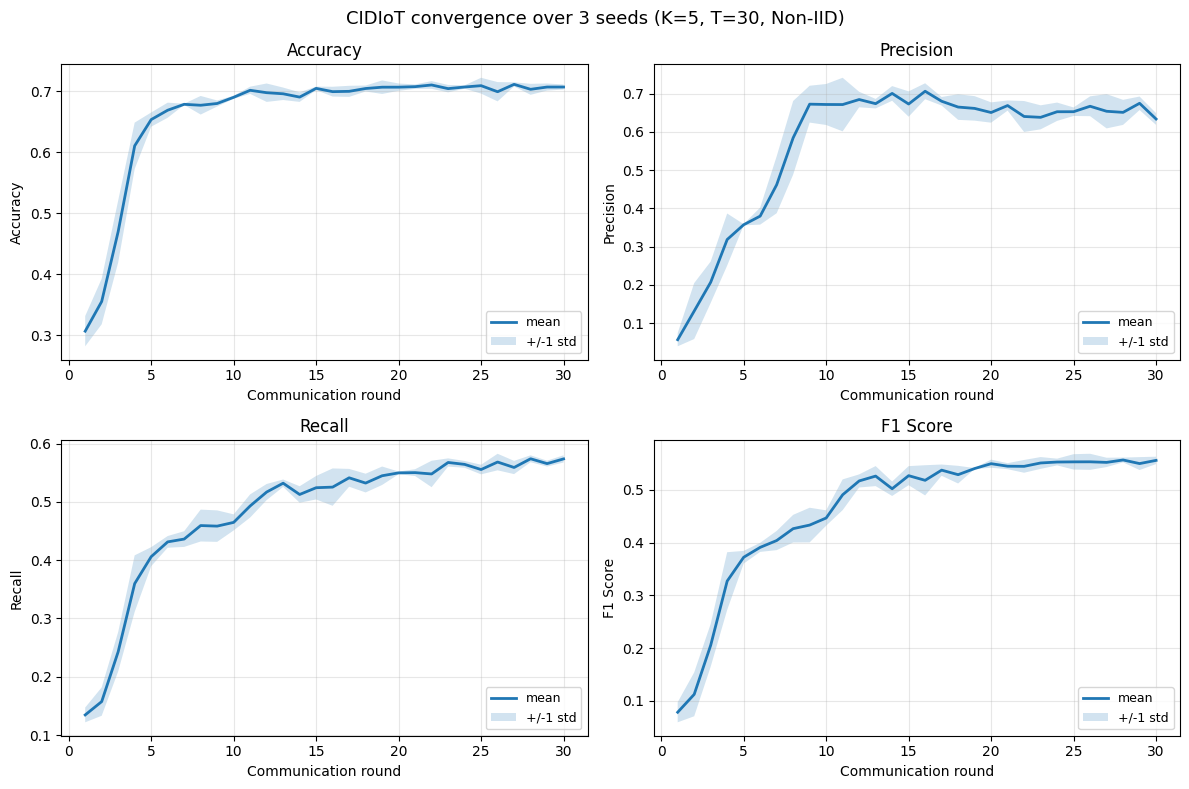

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
rounds = np.arange(1, NUM_ROUNDS + 1)

for ax, m in zip(axes.ravel(), metrics):
    stacked = np.array([all_histories[s][m] for s in RUN_SEEDS])
    mean = stacked.mean(0)
    std  = stacked.std(0)
    ax.plot(rounds, mean, linewidth=2, label="mean")
    ax.fill_between(rounds, mean - std, mean + std, alpha=0.2, label="+/-1 std")
    ax.set_title(metric_labels[m])
    ax.set_xlabel("Communication round")
    ax.set_ylabel(metric_labels[m])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle(f"CIDIoT convergence over {len(RUN_SEEDS)} seeds "
             f"(K={NUM_CLIENTS}, T={NUM_ROUNDS}, Non-IID)", fontsize=13)
fig.tight_layout()
plt.show()

## 14. Persist results

In [17]:
per_seed_df.to_csv("cidiot_per_seed_metrics.csv")
summary.round(6).to_csv("cidiot_summary_mean_std.csv")
report_df.to_csv("cidiot_report_table.csv")
print("Saved: cidiot_per_seed_metrics.csv, cidiot_summary_mean_std.csv, cidiot_report_table.csv")

Saved: cidiot_per_seed_metrics.csv, cidiot_summary_mean_std.csv, cidiot_report_table.csv
